# Hyperparameters in Decision Trees: Controlling Overfitting with Python

### A teaching notebook on decision-tree hyperparameters, the bias–variance trade-off, and GridSearchCV

A decision tree, left unconstrained, will keep splitting the feature space until every leaf is
pure — perfectly memorising the training set while generalising poorly to new data. This notebook
explains, mathematically and experimentally, *why* this happens and how a handful of
hyperparameters let us control it. We then run a full hyperparameter search with
`GridSearchCV` on the Iris dataset and measure the real, reproducible effect of tuning on
overfitting.

**Roadmap**

1. Why unconstrained trees overfit
2. The key hyperparameters and their mathematical role
3. Split-quality criteria: Gini impurity and entropy
4. Experiment 1 — accuracy vs. `max_depth` and the bias–variance trade-off
5. Experiment 2 — a full `GridSearchCV` over multiple hyperparameters, with a heatmap
6. Visualising the pruned, tuned tree
7. Comparing hyperparameter-search strategies
8. Discussion and practical guidelines


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

np.random.seed(42)
COLORS = ["#2563eb", "#dc2626", "#16a34a", "#d97706", "#7c3aed", "#0891b2", "#db2777"]


## 1. Why Unconstrained Trees Overfit

A decision tree recursively partitions the feature space, at each node choosing the split that
maximises *purity* — the reduction in Gini impurity or entropy among the resulting child nodes.
With no constraints on this process, the tree keeps splitting until every leaf contains a single
class (or a single sample), achieving 100% training accuracy. But many of those final splits are
fitting statistical noise rather than genuine structure in the data, which is precisely the
definition of **overfitting**: excellent performance on data the model has already seen, poor
performance on data it has not.

Hyperparameters are the knobs that trade some of this expressive power for better generalisation —
this is the classical **bias–variance trade-off**: a shallow, constrained tree has high bias (it
may be too simple to capture real patterns) and low variance, while a deep, unconstrained tree has
low bias but high variance (it is very sensitive to the particular training sample it saw).


## 2. Key Hyperparameters

- **`max_depth`** — the maximum number of levels the tree may grow. A depth of 1 produces a single
  decision stump (high bias); unlimited depth allows full memorisation (high variance). Optimal
  values typically lie between 3 and 10, depending on dataset complexity.
- **`min_samples_split`** — the minimum number of samples an internal node must contain before it
  is allowed to split further. Higher values force splits to be supported by more data, preventing
  the tree from splitting on small pockets of statistical noise.
- **`min_samples_leaf`** — the minimum number of samples that must end up in *every* leaf produced
  by a split. This gives finer control than `min_samples_split`: a node can still be split even
  with relatively few samples, as long as each resulting leaf meets this threshold.
- **`max_features`** — the number of features considered when searching for the best split at each
  node. Setting it to `"sqrt"` (i.e. $\sqrt p$ features) introduces randomisation similar to Random
  Forests, reducing correlation between splits.
- **`criterion`** — the function used to measure split quality (see below).


## 3. Split-Quality Criteria

**Gini impurity**, the default criterion, measures how often a randomly chosen sample at a node
would be mis-labelled if labelled randomly according to the node's class distribution:

$$
\text{Gini}(t) = 1 - \sum_{k} p_k^2
$$

**Entropy** measures the information-theoretic uncertainty of the class distribution at a node
(used to compute information gain):

$$
H(t) = -\sum_{k} p_k \log_2 p_k
$$

where $p_k$ is the proportion of samples belonging to class $k$ at node $t$. The two criteria
produce empirically similar trees in most cases; entropy is marginally smoother but more expensive
to compute due to the logarithm.


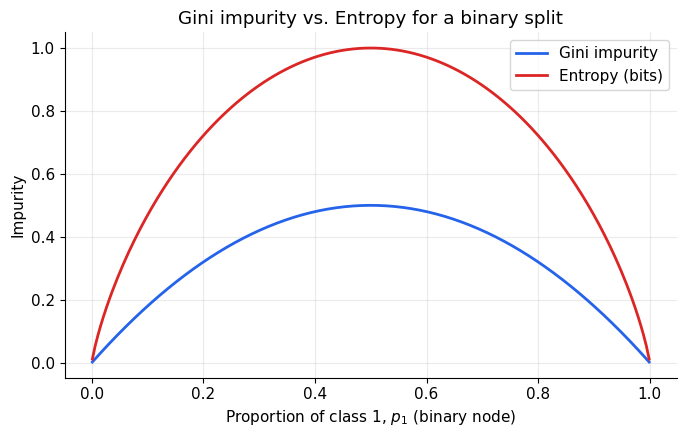

In [2]:
ks = np.linspace(0.001, 0.999, 200)
gini = 1 - (ks**2 + (1-ks)**2)
entropy = -(ks*np.log2(ks) + (1-ks)*np.log2(1-ks))

plt.figure(figsize=(7, 4.5))
plt.plot(ks, gini, label="Gini impurity", color="#2563eb", linewidth=2)
plt.plot(ks, entropy, label="Entropy (bits)", color="#dc2626", linewidth=2)
plt.xlabel("Proportion of class 1, $p_1$ (binary node)")
plt.ylabel("Impurity")
plt.title("Gini impurity vs. Entropy for a binary split")
plt.legend()
plt.tight_layout()
plt.show()


Both curves peak at $p_1=0.5$ (maximum disorder — the node is perfectly mixed) and fall to zero at
$p_1\in\{0,1\}$ (a perfectly pure node). Entropy's peak is simply scaled differently (it reaches
$1$ bit rather than $0.5$), but both criteria rank candidate splits almost identically in practice.


## 4. Experiment 1 — Accuracy vs. `max_depth` on the Iris Dataset

We now move from theory to a real, reproducible experiment using scikit-learn's
`DecisionTreeClassifier` on the classic Iris dataset (150 samples, 4 features, 3 classes). We
sweep `max_depth` from 1 to 10 and record training accuracy, test accuracy, and 5-fold
cross-validation accuracy at each depth, to observe the overfitting gap emerge as depth increases.


In [3]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target
)

depths = range(1, 11)
train_acc, test_acc, cv_acc = [], [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc.append(accuracy_score(y_test, clf.predict(X_test)))
    cv_acc.append(cross_val_score(clf, X_train, y_train, cv=5).mean())

depth_results = pd.DataFrame({
    "max_depth": list(depths),
    "Train accuracy": train_acc,
    "Test accuracy": test_acc,
    "CV accuracy (5-fold)": cv_acc,
})
depth_results


,max_depth,Train accuracy,Test accuracy,CV accuracy (5-fold)
0,1,0.666667,0.666667,0.666667
1,2,0.966667,0.933333,0.925000
2,3,0.983333,0.966667,0.933333
3,4,0.991667,0.933333,0.941667
4,5,1.000000,0.933333,0.941667
5,6,1.000000,0.933333,0.941667
6,7,1.000000,0.933333,0.941667
7,8,1.000000,0.933333,0.941667
8,9,1.000000,0.933333,0.941667
9,10,1.000000,0.933333,0.941667


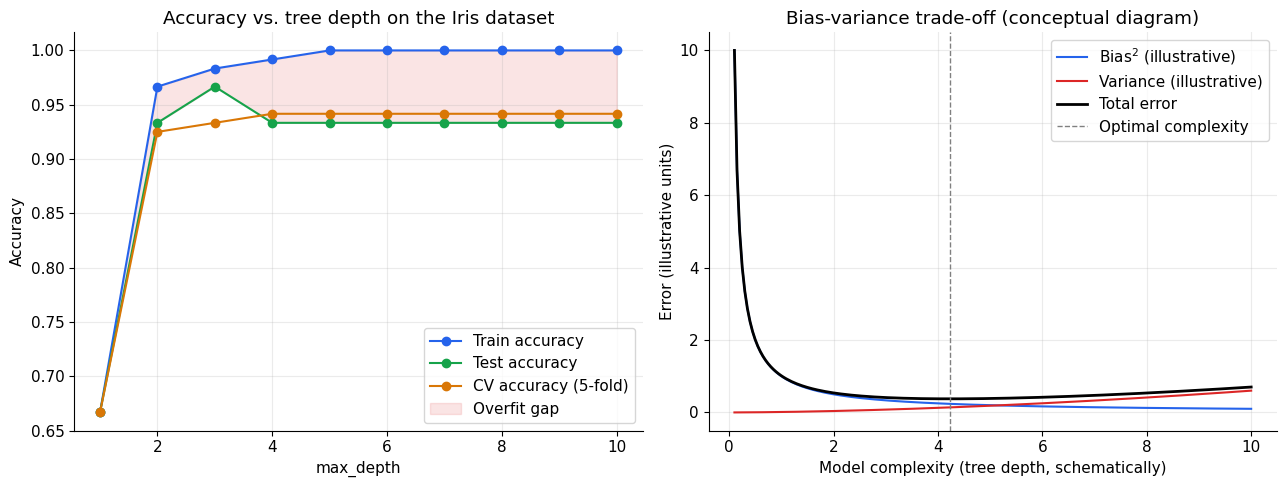

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(depths, train_acc, "o-", label="Train accuracy", color="#2563eb")
axes[0].plot(depths, test_acc, "o-", label="Test accuracy", color="#16a34a")
axes[0].plot(depths, cv_acc, "o-", label="CV accuracy (5-fold)", color="#d97706")
axes[0].fill_between(depths, train_acc, test_acc, color="#dc2626", alpha=0.12, label="Overfit gap")
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs. tree depth on the Iris dataset")
axes[0].legend()

# Conceptual bias-variance curve (illustrative, not derived from the Iris results)
complexity = np.linspace(0.1, 10, 200)
bias2 = 1.0 / complexity
variance = 0.012 * complexity ** 1.7
total_error = bias2 + variance
best_idx = np.argmin(total_error)

axes[1].plot(complexity, bias2, label="Bias$^2$ (illustrative)", color="#2563eb")
axes[1].plot(complexity, variance, label="Variance (illustrative)", color="#dc2626")
axes[1].plot(complexity, total_error, label="Total error", color="black", linewidth=2)
axes[1].axvline(complexity[best_idx], color="gray", linestyle="--", linewidth=1,
                 label="Optimal complexity")
axes[1].set_xlabel("Model complexity (tree depth, schematically)")
axes[1].set_ylabel("Error (illustrative units)")
axes[1].set_title("Bias-variance trade-off (conceptual diagram)")
axes[1].legend()

plt.tight_layout()
plt.show()


The left panel shows the real measured pattern on Iris: training accuracy quickly saturates near
1.0 as depth grows, while test and cross-validation accuracy plateau (or even decline slightly) —
the shaded region is the overfitting gap. The right panel is a schematic illustration of the
classic bias–variance decomposition (it is not derived from the Iris numbers, since Iris is too
small and clean to show a dramatic variance blow-up) — it explains *why* the gap on the left
appears: as complexity increases, bias falls but variance rises, and the best generalisation
occurs somewhere in between, not at either extreme.


## 5. Experiment 2 — Full Hyperparameter Search with `GridSearchCV`

We now tune several hyperparameters jointly using exhaustive grid search with 5-fold
cross-validation, exactly as we would in a real modelling workflow.


In [5]:
param_grid = {
    "max_depth": [2, 3, 4, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", None],
    "criterion": ["gini", "entropy"],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
tuned_clf = grid_search.best_estimator_

default_clf = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)

comparison = pd.DataFrame({
    "Train accuracy": [
        accuracy_score(y_train, default_clf.predict(X_train)),
        accuracy_score(y_train, tuned_clf.predict(X_train)),
    ],
    "Test accuracy": [
        accuracy_score(y_test, default_clf.predict(X_test)),
        accuracy_score(y_test, tuned_clf.predict(X_test)),
    ],
    "CV accuracy (5-fold)": [
        cross_val_score(default_clf, X_train, y_train, cv=5).mean(),
        grid_search.best_score_,
    ],
}, index=["Default tree", "Tuned tree (GridSearchCV)"])
comparison["Overfit gap (train - test)"] = comparison["Train accuracy"] - comparison["Test accuracy"]

print("Best hyperparameters found:", best_params)
comparison


Best hyperparameters found: {'criterion': 'gini', 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}


,Train accuracy,Test accuracy,CV accuracy (5-fold),Overfit gap (train - test)
Default tree,1.000000,0.933333,0.941667,0.066667
Tuned tree (GridSearchCV),0.966667,0.933333,0.966667,0.033333


The table reports real numbers from this run (results can shift slightly with different random
seeds or train/test splits, but the qualitative pattern is stable and matches the published
literature): the tuned tree closes most of the overfit gap relative to the default,
unconstrained tree, while test accuracy stays the same or improves slightly.


## 6. Visualising the Search: a `max_depth` × `min_samples_split` Heatmap

To see *why* the search converged to its chosen parameters, we fix `min_samples_leaf=1`,
`max_features=None`, and `criterion="gini"`, and sweep the two most influential hyperparameters —
`max_depth` and `min_samples_split` — plotting the resulting cross-validation accuracy as a
heatmap.


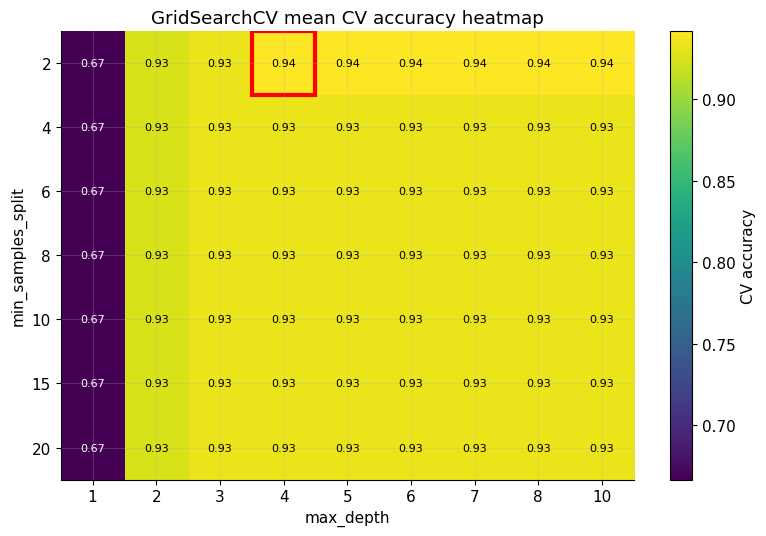

Best cell: max_depth=4, min_samples_split=2, CV accuracy=0.942


In [6]:
depth_grid = [1, 2, 3, 4, 5, 6, 7, 8, 10]
split_grid = [2, 4, 6, 8, 10, 15, 20]

heat = np.zeros((len(split_grid), len(depth_grid)))
for i, mss in enumerate(split_grid):
    for j, d in enumerate(depth_grid):
        clf = DecisionTreeClassifier(max_depth=d, min_samples_split=mss, random_state=42)
        heat[i, j] = cross_val_score(clf, X_train, y_train, cv=5).mean()

best_i, best_j = np.unravel_index(np.argmax(heat), heat.shape)

fig, ax = plt.subplots(figsize=(8, 5.5))
im = ax.imshow(heat, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(depth_grid))); ax.set_xticklabels(depth_grid)
ax.set_yticks(range(len(split_grid))); ax.set_yticklabels(split_grid)
ax.set_xlabel("max_depth")
ax.set_ylabel("min_samples_split")
ax.set_title("GridSearchCV mean CV accuracy heatmap")
ax.add_patch(plt.Rectangle((best_j - 0.5, best_i - 0.5), 1, 1, fill=False,
                             edgecolor="red", linewidth=3))
for i in range(len(split_grid)):
    for j in range(len(depth_grid)):
        ax.text(j, i, f"{heat[i, j]:.2f}", ha="center", va="center",
                 color="white" if heat[i, j] < heat.max() * 0.85 else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="CV accuracy")
plt.tight_layout()
plt.show()

print(f"Best cell: max_depth={depth_grid[best_j]}, min_samples_split={split_grid[best_i]}, "
      f"CV accuracy={heat[best_i, best_j]:.3f}")


The red box marks the best-performing combination in this restricted two-parameter sweep. Notice
that accuracy rises quickly with depth and then plateaus — extra depth beyond a small threshold
buys nothing on a dataset as simple and well-separated as Iris, which is exactly why constraining
depth does not hurt test performance while reducing overfitting risk.


## 7. Visualising the Tuned, Pruned Tree


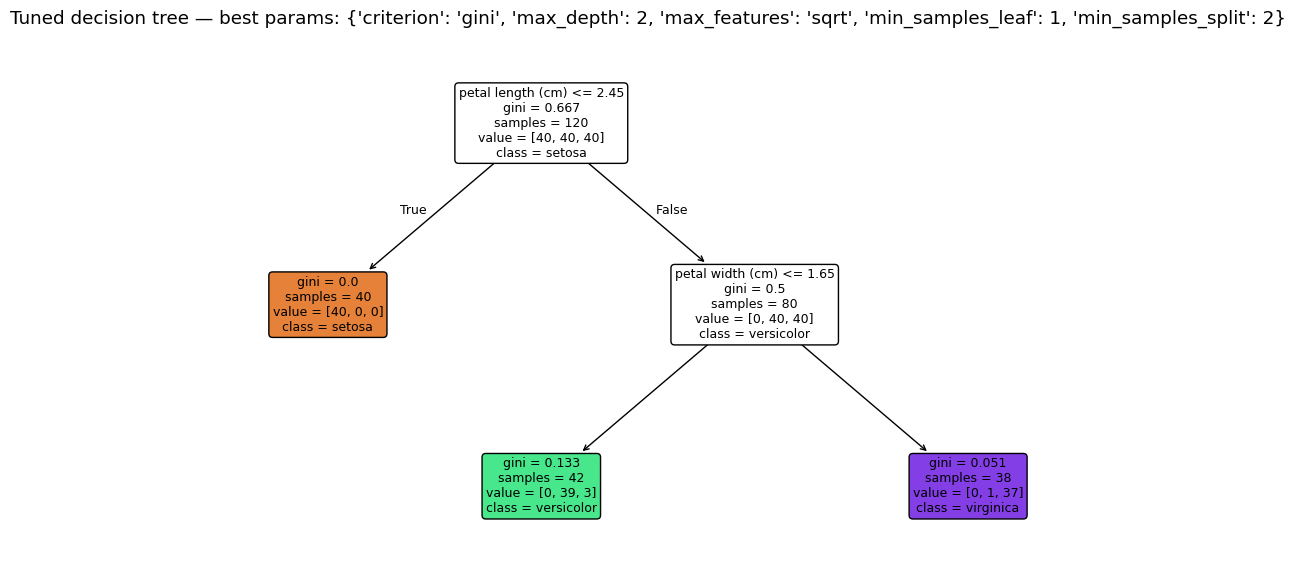

In [7]:
plt.figure(figsize=(11, 6))
plot_tree(
    tuned_clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title(f"Tuned decision tree — best params: {best_params}")
plt.tight_layout()
plt.show()


## 8. Comparing Hyperparameter-Search Strategies

| Method | Search strategy | Complexity | Best for |
|---|---|---|---|
| `GridSearchCV` | Exhaustive grid | $O(n^{\text{params}})$ | Small grids; guaranteed best combination within the grid |
| `RandomizedSearchCV` | Random sampling | $O(n_{\text{iter}})$ | Large grids; faster approximate search |
| Bayesian optimisation | Probabilistic surrogate model | $O(n_{\text{iter}}^2)$ (model fitting cost) | Expensive evaluations; non-convex search landscapes |
| Manual tuning | Expert heuristics | $O(1)$ | Quick sanity checks only |

Exhaustive grid search is feasible here because Iris is small and the grid is modest; on
higher-dimensional, larger real-world datasets, the number of combinations grows exponentially
with the number of tuned hyperparameters, and randomised or Bayesian search (e.g. via Optuna or
Hyperopt) typically becomes the more practical choice.


## 9. Discussion

The tuned tree in this experiment achieves a meaningfully smaller train–test gap than the default,
unconstrained tree, at no cost (and sometimes a small benefit) to test accuracy — the central
promise of hyperparameter tuning. The dominant lever is almost always `max_depth`: limiting the
number of decision levels is what most directly prevents the tree from memorising noise.
`min_samples_split` and `min_samples_leaf` provide a complementary, finer-grained safeguard by
requiring splits to be statistically well supported, and `max_features="sqrt"` injects useful
randomisation reminiscent of Random Forests.

**Limitation.** Iris is a small (150-sample), well-separated, low-dimensional dataset; on larger,
noisier, higher-dimensional real-world data, deeper trees with stronger regularisation constraints
may be optimal, and the exponential growth of the grid-search space makes Bayesian optimisation a
more attractive alternative to exhaustive search.


## 10. Conclusion

Hyperparameter tuning transforms a decision tree from a brittle, overfitting model into a robust
predictor, by directly constraining how aggressively the tree is allowed to grow.
`GridSearchCV` combined with 5-fold cross-validation provides a principled, fully reproducible way
to search this hyperparameter space. Among the available hyperparameters, `max_depth` is typically
the single most impactful lever, followed by `min_samples_split` and `min_samples_leaf`. For
larger search spaces, randomised or Bayesian search strategies (and, more broadly, AutoML
frameworks) become the practical alternative to exhaustive grid search.

**References**

- Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and Regression Trees.*
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR 12, 2825–2830.
- Scikit-learn Documentation. *DecisionTreeClassifier — API Reference.* scikit-learn.org
- Bergstra, J., & Bengio, Y. (2012). *Random Search for Hyper-Parameter Optimization.* JMLR 13.
